In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!pip install zarr gcsfs fsspec xarray --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 5.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 59.9 MB/s eta 0:00:0000:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
s3fs 2026.2.0 requires fsspec==2026.2.0, but you have fsspec 2025.3.0 which is incompatible.


In [3]:
import numpy as np
import torch
import torch.nn.functional as F
import xarray as xr
from torch.utils.data import Dataset
from huggingface_hub import hf_hub_download

In [4]:
zarr_path = "gs://weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr"

print("Loading ERA5...")
ds = xr.open_zarr(
    zarr_path,
    consolidated=True,
    storage_options={"token": "anon"}
)

Loading ERA5...


In [5]:
REPO_ID = "priyanshus9913/Result_MTP_12"

def load_gencast_year(year):

    ds_list = []

    for m in ["06", "08"]:
        filename = f"{year}_{m}/preds_combined_{year}_{m}.nc"

        path = hf_hub_download(
            repo_id=REPO_ID,
            filename=filename,
            repo_type="dataset"
        )

        print(f"Loaded: {filename}")

        ds = xr.open_dataset(path)

        ds = ds.isel(batch=0, time=0)
        ds = ds[["total_precipitation_12hr"]]

        ds_list.append(ds)

    ds = xr.concat(ds_list, dim="target_time")

    return ds

In [6]:
class ERA5SuperResDataset(Dataset):

    def __init__(self, ds, year, target_size=(36,41), months=[6,7,8,9]):

        print(f"\nBuilding ERA5 dataset for {year}")

        # -------------------------
        # Region
        # -------------------------
        ds = ds.sel(latitude=slice(40,5),
                    longitude=slice(60,100))

        # -------------------------
        # Time filter
        # -------------------------
        ds = ds.sel(time=slice(f"{year}", f"{year}"))
        ds = ds.sel(time=ds.time.dt.month.isin(months))

        print("Time steps:", len(ds.time))

        # -------------------------
        # TARGET (0.25°)
        # -------------------------
        tp = ds["total_precipitation_12hr"].values.astype(np.float32)

        tp *= 1000
        tp = np.log1p(tp)

        fine = torch.from_numpy(tp).unsqueeze(1)   # [T,1,141,161]

        print("Fine:", fine.shape)

        # -------------------------
        # INPUT (1° fixed grid)
        # -------------------------
        low = F.interpolate(
            fine,
            size=target_size,
            mode="bilinear"
        )

        print("Low:", low.shape)

        # -------------------------
        # NORMALIZATION
        # -------------------------
        self.mean = low.mean()
        self.std  = low.std()

        inputs = (low - self.mean) / self.std
        targets = (fine - fine.mean()) / fine.std()

        # -------------------------
        # STATICS (downsample to 1°)
        # -------------------------
        const_vars = ["land_sea_mask", "geopotential_at_surface"]

        consts = []
        for var in const_vars:
            arr = ds[var].values.astype(np.float32)
            arr = (arr - arr.mean()) / arr.std()
            consts.append(torch.from_numpy(arr))

        const = torch.stack(consts, 0)   # [C,141,161]

        const = F.interpolate(
            const.unsqueeze(0),
            size=target_size,
            mode="bilinear"
        )[0]

        print("Statics:", const.shape)

        const = const.unsqueeze(0).repeat(inputs.shape[0],1,1,1)

        inputs = torch.cat((inputs, const), dim=1)

        # -------------------------
        # TIME FEATURES
        # -------------------------
        t = ds.time.dt

        self.day_of_year = torch.from_numpy(
            ((t.month.values-1)*30)/360
        ).float()

        self.hour = torch.from_numpy(
            t.hour.values/24
        ).float()

        # -------------------------
        # STORE
        # -------------------------
        self.inputs = inputs
        self.targets = targets

        print("\nFINAL TRAIN SHAPES")
        print("Inputs :", self.inputs.shape)
        print("Targets:", self.targets.shape)


    def __len__(self):
        return len(self.inputs)


    def __getitem__(self, idx):
        return {
            "inputs": self.inputs[idx],     # [3,36,41]
            "targets": self.targets[idx],   # [1,141,161]
            "day_of_year": self.day_of_year[idx],
            "hour": self.hour[idx]
        }

In [7]:
train_ds = ERA5SuperResDataset(ds, year=2018)
valid_ds = ERA5SuperResDataset(ds, year=2019)


Building ERA5 dataset for 2018
Time steps: 488
Fine: torch.Size([488, 1, 141, 161])
Low: torch.Size([488, 1, 36, 41])
Statics: torch.Size([2, 36, 41])

FINAL TRAIN SHAPES
Inputs : torch.Size([488, 3, 36, 41])
Targets: torch.Size([488, 1, 141, 161])

Building ERA5 dataset for 2019
Time steps: 488
Fine: torch.Size([488, 1, 141, 161])
Low: torch.Size([488, 1, 36, 41])
Statics: torch.Size([2, 36, 41])

FINAL TRAIN SHAPES
Inputs : torch.Size([488, 3, 36, 41])
Targets: torch.Size([488, 1, 141, 161])


In [8]:
class GenCastTestDataset(Dataset):

    def __init__(self, gencast_ds, era5_ds, train_ds, target_size=(36,41)):

        print("\nBuilding GenCast test dataset")

        # -------------------------
        # GenCast region
        # -------------------------
        gencast_ds = gencast_ds.sel(
            lat=slice(5,40),
            lon=slice(60,100)
        )

        gencast_ds = gencast_ds.sortby("lat", ascending=False)

        # -------------------------
        # GenCast input
        # -------------------------
        tp = gencast_ds["total_precipitation_12hr"].values.astype(np.float32)

        tp *= 1000
        tp = np.log1p(tp)

        inputs = torch.from_numpy(tp).unsqueeze(1)

        print("GenCast:", inputs.shape)

        # -------------------------
        # ERA5 truth
        # -------------------------
        era5_ds = era5_ds.sel(latitude=slice(40,5),
                             longitude=slice(60,100))

        tp = era5_ds["total_precipitation_12hr"].values.astype(np.float32)

        tp *= 1000
        tp = np.log1p(tp)

        targets = torch.from_numpy(tp).unsqueeze(1)

        print("ERA5:", targets.shape)

        # -------------------------
        # ALIGN TIME
        # -------------------------
        min_len = min(len(inputs), len(targets))

        inputs  = inputs[:min_len]
        targets = targets[:min_len]

        # -------------------------
        # NORMALIZE
        # -------------------------
        inputs = (inputs - train_ds.mean) / train_ds.std
        targets = (targets - targets.mean()) / targets.std()

        # -------------------------
        # STATICS (reuse train)
        # -------------------------
        const = train_ds.inputs[0,1:]   # already (36,41)

        const = const.unsqueeze(0).repeat(inputs.shape[0],1,1,1)

        inputs = torch.cat((inputs, const), dim=1)

        # -------------------------
        # TIME FEATURES
        # -------------------------
        t = gencast_ds.target_time.dt

        self.day_of_year = torch.from_numpy(
            ((t.month.values-1)*30)/360
        ).float()[:min_len]

        self.hour = torch.from_numpy(
            t.hour.values/24
        ).float()[:min_len]

        # -------------------------
        # STORE
        # -------------------------
        self.inputs = inputs
        self.targets = targets

        print("\nFINAL TEST SHAPES")
        print("Inputs :", self.inputs.shape)
        print("Targets:", self.targets.shape)


    def __len__(self):
        return len(self.inputs)


    def __getitem__(self, idx):
        return {
            "inputs": self.inputs[idx],
            "targets": self.targets[idx],
            "day_of_year": self.day_of_year[idx],
            "hour": self.hour[idx]
        }

In [9]:
# huggingface-cli login

In [10]:
gencast_ds = load_gencast_year(2019)

2019_06/preds_combined_2019_06.nc:   0%|          | 0.00/1.87G [00:00<?, ?B/s]

Loaded: 2019_06/preds_combined_2019_06.nc


2019_08/preds_combined_2019_08.nc:   0%|          | 0.00/1.87G [00:00<?, ?B/s]

Loaded: 2019_08/preds_combined_2019_08.nc


In [11]:
era5_2019 = ds.sel(time=slice("2019","2019"))
era5_2019 = era5_2019.sel(time=era5_2019.time.dt.month.isin([6,7,8,9]))

test_ds = GenCastTestDataset(
    gencast_ds,
    era5_2019,
    train_ds
)


Building GenCast test dataset
GenCast: torch.Size([242, 1, 36, 41])
ERA5: torch.Size([488, 1, 141, 161])

FINAL TEST SHAPES
Inputs : torch.Size([242, 3, 36, 41])
Targets: torch.Size([242, 1, 141, 161])


In [12]:
import matplotlib.pyplot as plt

def visualize_triplet(train_ds, test_ds, idx=0):

    # -------------------------
    # ERA5 TRAIN (low + high)
    # -------------------------
    train_sample = train_ds[idx]

    era5_low  = train_sample["inputs"][0]   # precipitation channel (1°)
    era5_high = train_sample["targets"][0]  # 0.25°

    # -------------------------
    # GenCast TEST (input)
    # -------------------------
    test_sample = test_ds[idx]

    gencast = test_sample["inputs"][0]   # precipitation channel (1°)
    truth   = test_sample["targets"][0]  # ERA5 truth

    # -------------------------
    # Plot
    # -------------------------
    fig, ax = plt.subplots(1,4, figsize=(18,4))

    titles = [
        "GenCast (1° Input)",
        "ERA5 Low (1° Train)",
        "ERA5 High (0.25° Truth)",
        "ERA5 Truth (Test)"
    ]

    imgs = [gencast, era5_low, era5_high, truth]

    for i in range(4):
        im = ax[i].imshow(imgs[i])
        ax[i].set_title(titles[i])
        ax[i].axis("off")
        plt.colorbar(im, ax=ax[i])

    plt.tight_layout()
    plt.show()

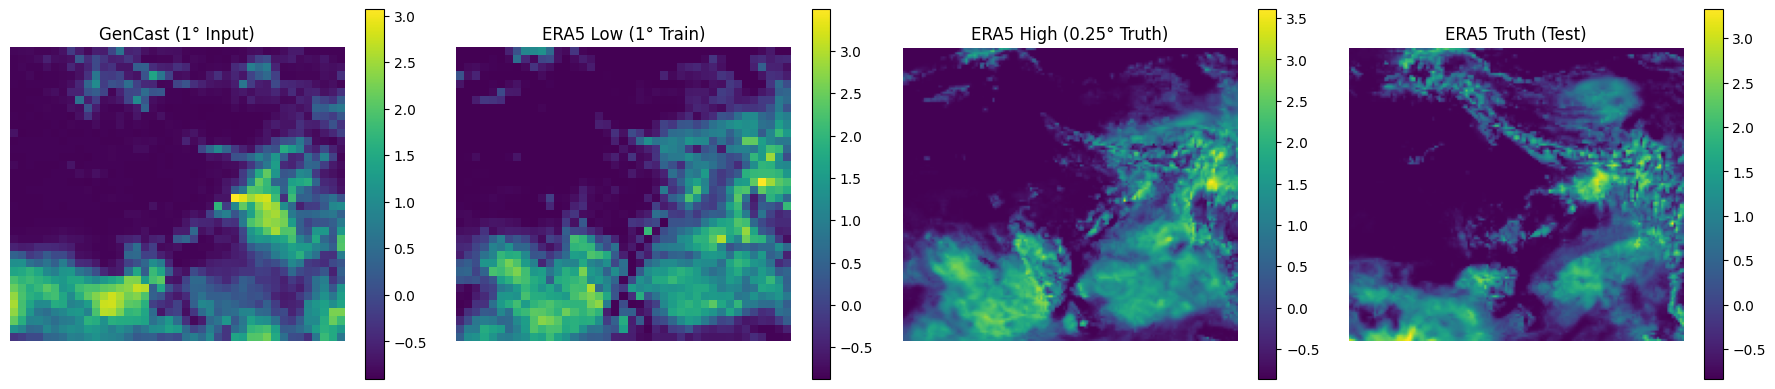

In [13]:
visualize_triplet(train_ds, test_ds, idx=10)

In [14]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import torch.nn.functional as F
import numpy as np

def visualize_1deg_aligned(gencast_ds, era5_ds, idx=0):

    proj = ccrs.PlateCarree()
    extent = [60, 100, 5, 40]

    # -------------------------
    # GenCast (1°)
    # -------------------------
    g = gencast_ds["total_precipitation_12hr"].isel(target_time=idx)

    g = g.sel(lat=slice(5,40), lon=slice(60,100))
    g = g.sortby("lat", ascending=False)

    g = (g.values.astype(np.float32) * 1000)
    g = np.log1p(g)

    g_tensor = torch.from_numpy(g).unsqueeze(0).unsqueeze(0)  # [1,1,H,W]

    Hg, Wg = g_tensor.shape[-2:]

    # -------------------------
    # ERA5 (same time → 0.25°)
    # -------------------------
    t = gencast_ds.target_time.values[idx]

    e = era5_ds.sel(time=t)

    e = e.sel(latitude=slice(40,5),
              longitude=slice(60,100))

    e = e["total_precipitation_12hr"].values.astype(np.float32)

    e = e * 1000
    e = np.log1p(e)

    e_tensor = torch.from_numpy(e).unsqueeze(0).unsqueeze(0)

    # -------------------------
    # Downsample ERA5 → 1°
    # -------------------------
    e_low = F.interpolate(
        e_tensor,
        size=(Hg, Wg),
        mode="bilinear"
    )[0,0].numpy()

    g = g_tensor[0,0].numpy()

    # -------------------------
    # Plot
    # -------------------------
    fig, axes = plt.subplots(
        1, 2,
        figsize=(12,5),
        subplot_kw={"projection": proj}
    )

    titles = ["GenCast (1°)", "ERA5 → 1° (same time)"]
    data = [g, e_low]

    for i, ax in enumerate(axes):
        ax.set_extent(extent, crs=proj)

        im = ax.imshow(
            data[i],
            origin="upper",
            extent=extent,
            transform=proj
        )

        ax.coastlines(resolution="50m")
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)
        ax.set_title(titles[i])

        plt.colorbar(im, ax=ax, shrink=0.7)

    plt.tight_layout()
    plt.show()

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


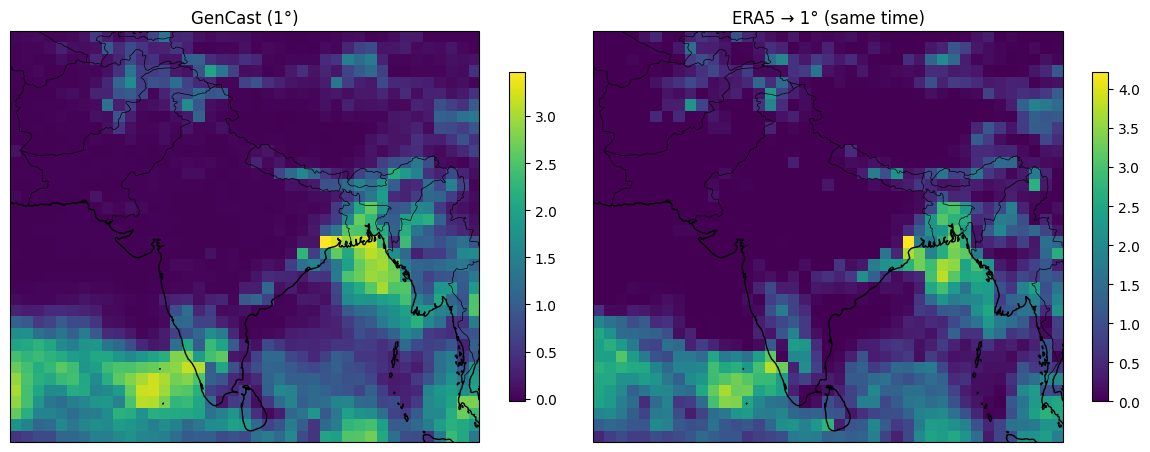

In [15]:
visualize_1deg_aligned(gencast_ds, ds, idx=10)

In [16]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import torch
import torch.nn.functional as F
import numpy as np

def visualize_full_pipeline(gencast_ds, train_ds, era5_ds, idx=0):

    proj = ccrs.PlateCarree()
    extent = [60, 100, 5, 40]

    # =========================
    # 1. GenCast (1°)
    # =========================
    g = gencast_ds["total_precipitation_12hr"].isel(target_time=idx)

    g = g.sel(lat=slice(5,40), lon=slice(60,100))
    g = g.sortby("lat", ascending=False)

    g = g.values.astype(np.float32) * 1000
    g = np.log1p(g)

    g_tensor = torch.from_numpy(g).unsqueeze(0).unsqueeze(0)

    # =========================
    # 2. GenCast → 0.25°
    # =========================
    Ht, Wt = train_ds.targets.shape[-2:]

    g_up = F.interpolate(
        g_tensor,
        size=(Ht, Wt),
        mode="bilinear"
    )[0,0].numpy()

    # =========================
    # 3. ERA5 (same time)
    # =========================
    t = gencast_ds.target_time.values[idx]

    e = era5_ds.sel(time=t)
    e = e.sel(latitude=slice(40,5),
              longitude=slice(60,100))

    e = e["total_precipitation_12hr"].values.astype(np.float32)
    e = e * 1000
    e = np.log1p(e)

    e_tensor = torch.from_numpy(e).unsqueeze(0).unsqueeze(0)

    # =========================
    # 4. ERA5 → 1°
    # =========================
    Hg, Wg = g.shape

    e_low = F.interpolate(
        e_tensor,
        size=(Hg, Wg),
        mode="bilinear"
    )[0,0].numpy()

    e_high = e

    # =========================
    # PLOT
    # =========================
    fig, axes = plt.subplots(
        2, 2,
        figsize=(14,10),
        subplot_kw={"projection": proj}
    )

    titles = [
        "GenCast (1°)",
        "GenCast → 0.25°",
        "ERA5 → 1°",
        "ERA5 (0.25° Truth)"
    ]

    data = [
        g,
        g_up,
        e_low,
        e_high
    ]

    for i, ax in enumerate(axes.flat):
        ax.set_extent(extent, crs=proj)

        im = ax.imshow(
            data[i],
            origin="upper",
            extent=extent,
            transform=proj
        )

        ax.coastlines(resolution="50m")
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)
        ax.set_title(titles[i])

        plt.colorbar(im, ax=ax, shrink=0.7)

    plt.tight_layout()
    plt.show()

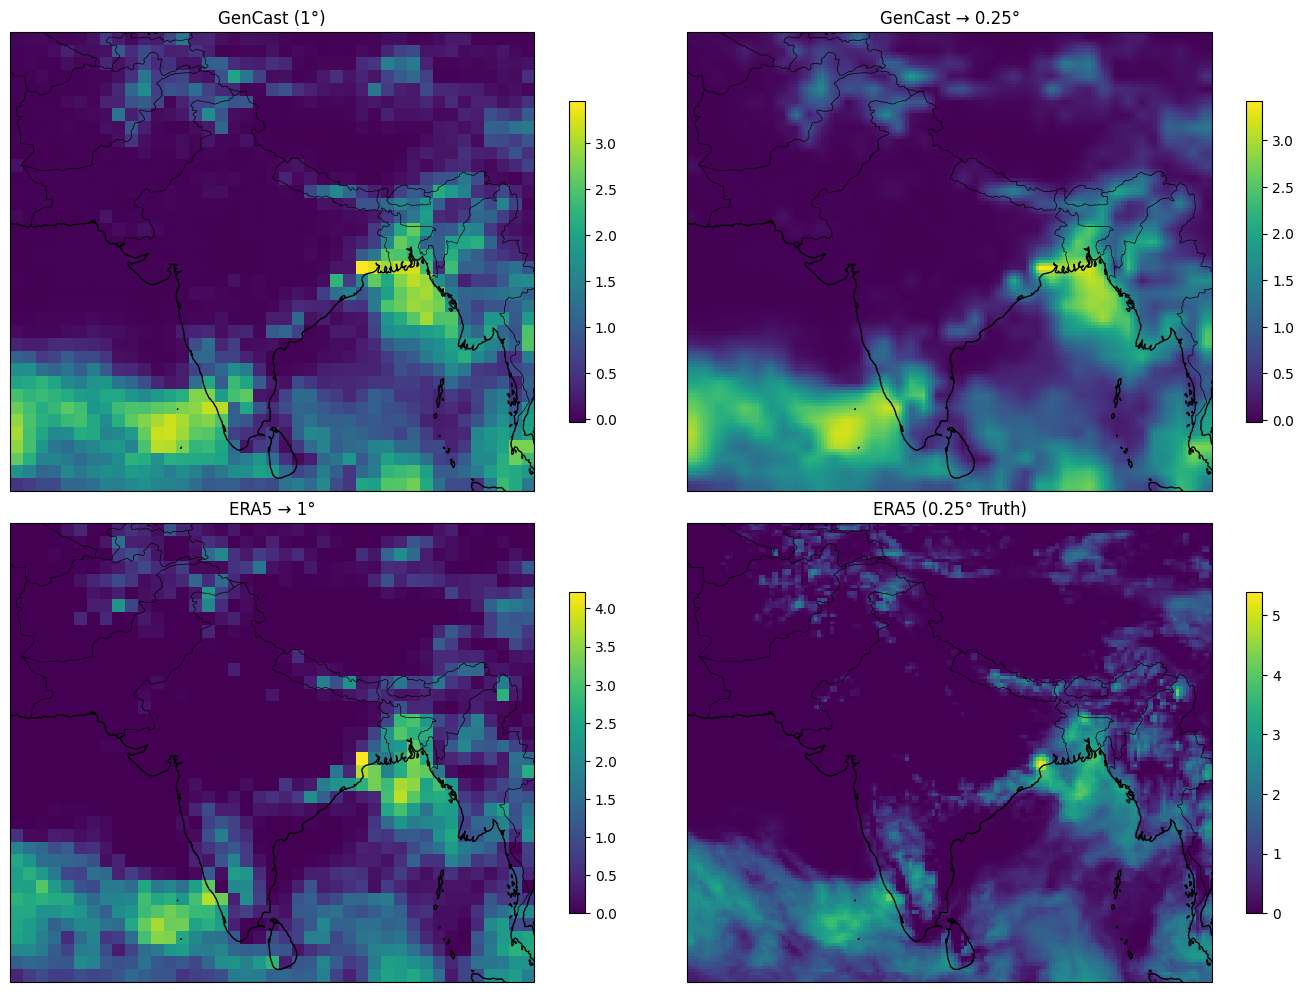

In [17]:
visualize_full_pipeline(gencast_ds, train_ds, ds, idx=10)

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm import tqdm

In [19]:
def match_size(x, ref):
    return F.interpolate(x, size=ref.shape[-2:], mode="bilinear", align_corners=False)

In [20]:
class Block(nn.Module):
    def __init__(self, in_c, out_c, emb_dim):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.GroupNorm(8, out_c),
            nn.SiLU(),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.GroupNorm(8, out_c),
            nn.SiLU()
        )

        self.emb = nn.Linear(emb_dim, out_c)

    def forward(self, x, e):
        h = self.conv(x)
        emb = self.emb(e).unsqueeze(-1).unsqueeze(-1)
        return h + emb

In [21]:
class UNet(nn.Module):

    def __init__(self, in_c=3, out_c=1):
        super().__init__()

        base = 32
        emb_dim = 128

        # embedding
        self.embed = nn.Sequential(
            nn.Linear(2, emb_dim),
            nn.SiLU(),
            nn.Linear(emb_dim, emb_dim)
        )

        self.pool = nn.MaxPool2d(2)
        self.up   = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)

        # encoder
        self.d1 = Block(in_c, base, emb_dim)
        self.d2 = Block(base, base*2, emb_dim)
        self.d3 = Block(base*2, base*4, emb_dim)

        # bottleneck
        self.mid = Block(base*4, base*8, emb_dim)

        # decoder
        self.u3 = Block(base*8 + base*4, base*4, emb_dim)
        self.u2 = Block(base*4 + base*2, base*2, emb_dim)
        self.u1 = Block(base*2 + base, base, emb_dim)

        self.out = nn.Conv2d(base, out_c, 1)

    def forward(self, x, cond):

        # 🔥 upscale input FIRST
        x = F.interpolate(x, size=(141, 161), mode="bilinear", align_corners=False)

        e = self.embed(cond)

        # encoder
        d1 = self.d1(x, e)
        d2 = self.d2(self.pool(d1), e)
        d3 = self.d3(self.pool(d2), e)

        # bottleneck
        m = self.mid(self.pool(d3), e)

        # decoder (FIXED)
        u3 = self.up(m)
        u3 = match_size(u3, d3)
        u3 = self.u3(torch.cat([u3, d3], 1), e)

        u2 = self.up(u3)
        u2 = match_size(u2, d2)
        u2 = self.u2(torch.cat([u2, d2], 1), e)

        u1 = self.up(u2)
        u1 = match_size(u1, d1)
        u1 = self.u1(torch.cat([u1, d1], 1), e)

        return self.out(u1)

In [22]:
def compute_metrics(pred, gt):
    mse = ((pred - gt)**2).mean().item()
    mae = (pred - gt).abs().mean().item()
    r2  = 1 - ((pred - gt)**2).sum() / ((gt - gt.mean())**2).sum()
    return mse, mae, r2.item()

In [23]:
def train_epoch(model, loader, opt, loss_fn, device):

    model.train()
    total_loss = 0

    for batch in tqdm(loader):

        x = batch["inputs"].to(device)
        y = batch["targets"].to(device)

        cond = torch.stack(
            (batch["day_of_year"], batch["hour"]), 1
        ).to(device)

        pred = model(x, cond)

        loss = loss_fn(pred, y)

        opt.zero_grad()
        loss.backward()
        opt.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [24]:
@torch.no_grad()
def evaluate(model, loader, device):

    model.eval()

    preds, gts = [], []

    for batch in loader:

        x = batch["inputs"].to(device)
        y = batch["targets"]

        cond = torch.stack(
            (batch["day_of_year"], batch["hour"]), 1
        ).to(device)

        pred = model(x, cond).cpu()

        preds.append(pred)
        gts.append(y)

    preds = torch.cat(preds)
    gts   = torch.cat(gts)

    return compute_metrics(preds, gts)

In [25]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = UNet(in_c=3, out_c=1).to(device)

opt = torch.optim.AdamW(model.parameters(), lr=3e-4)
loss_fn = nn.MSELoss()

In [26]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=8, shuffle=False)

In [27]:
batch = next(iter(train_loader))

print("inputs :", batch["inputs"].shape)
print("targets:", batch["targets"].shape)
print("cond   :", batch["day_of_year"].shape)

inputs : torch.Size([8, 3, 36, 41])
targets: torch.Size([8, 1, 141, 161])
cond   : torch.Size([8])


In [28]:
x = batch["inputs"].to(device)

cond = torch.stack(
    (batch["day_of_year"], batch["hour"]), 1
).to(device)

out = model(x, cond)

print(out.shape)

torch.Size([8, 1, 141, 161])


In [29]:
for epoch in range(10):

    train_loss = train_epoch(model, train_loader, opt, loss_fn, device)

    mse, mae, r2 = evaluate(model, valid_loader, device)

    print(f"\nEpoch {epoch}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"MSE: {mse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f}")

100%|██████████| 61/61 [00:04<00:00, 13.88it/s]



Epoch 0
Train Loss: 0.1530
MSE: 0.0862 | MAE: 0.1930 | R2: 0.9138


100%|██████████| 61/61 [00:04<00:00, 15.16it/s]



Epoch 1
Train Loss: 0.0834
MSE: 0.0768 | MAE: 0.1701 | R2: 0.9232


100%|██████████| 61/61 [00:04<00:00, 15.04it/s]


...


Epoch 7
Train Loss: 0.0719
MSE: 0.0691 | MAE: 0.1561 | R2: 0.9309


100%|██████████| 61/61 [00:04<00:00, 14.38it/s]



Epoch 8
Train Loss: 0.0706
MSE: 0.0682 | MAE: 0.1540 | R2: 0.9318


100%|██████████| 61/61 [00:04<00:00, 14.28it/s]



Epoch 9
Train Loss: 0.0696
MSE: 0.0683 | MAE: 0.1591 | R2: 0.9317


In [30]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import torch
import numpy as np

@torch.no_grad()
def visualize_valid_raw(model, dataset, device, idx=0):

    model.eval()

    proj = ccrs.PlateCarree()
    extent = [60, 100, 5, 40]

    # -------------------------
    # Sample
    # -------------------------
    s = dataset[idx]

    x = s["inputs"].unsqueeze(0).to(device)
    y = s["targets"]

    cond = torch.stack(
        (s["day_of_year"].unsqueeze(0),
         s["hour"].unsqueeze(0)), 1
    ).to(device)

    # -------------------------
    # Model output (0.25°)
    # -------------------------
    pred = model(x, cond)[0,0].cpu().numpy()

    # -------------------------
    # Input (TRUE 1°)
    # -------------------------
    inp = s["inputs"][0].cpu().numpy()
    inp = inp * dataset.std.item() + dataset.mean.item()

    # -------------------------
    # Ground truth (0.25°)
    # -------------------------
    gt = y[0].cpu().numpy()

    # -------------------------
    # Error
    # -------------------------
    err = np.abs(pred - gt)

    # -------------------------
    # PLOT
    # -------------------------
    fig, axes = plt.subplots(
        2, 2,
        figsize=(12,10),
        subplot_kw={"projection": proj}
    )

    titles = [
        "Input (1°)",
        "Model Output (0.25°)",
        "ERA5 Truth (0.25°)",
        "Absolute Error"
    ]

    data = [
        inp,
        pred,
        gt,
        err
    ]

    for i, ax in enumerate(axes.flat):

        ax.set_extent(extent, crs=proj)

        im = ax.imshow(
            data[i],
            origin="upper",
            extent=extent,
            transform=proj
        )

        ax.coastlines(resolution="50m")
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)
        ax.set_title(titles[i])

        plt.colorbar(im, ax=ax, shrink=0.7)

    plt.tight_layout()
    plt.show()

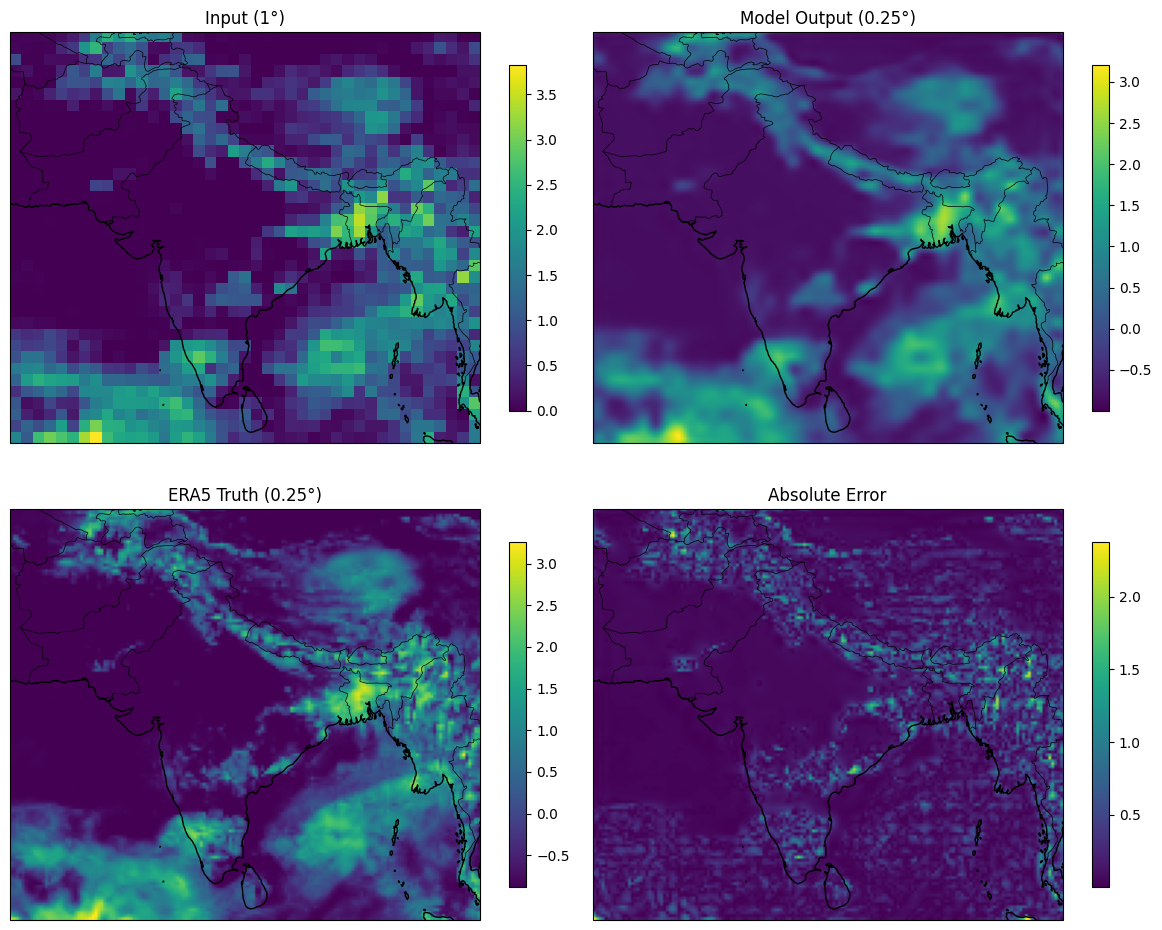

In [31]:
visualize_valid_raw(model, valid_ds, device, idx=10)

In [32]:
test_ds.train_mean = train_ds.mean
test_ds.train_std  = train_ds.std

In [33]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import torch
import numpy as np

@torch.no_grad()
def visualize_test_raw(model, dataset, device, idx=0):

    model.eval()

    proj = ccrs.PlateCarree()
    extent = [60, 100, 5, 40]

    # -------------------------
    # Sample
    # -------------------------
    s = dataset[idx]

    x = s["inputs"].unsqueeze(0).to(device)
    y = s["targets"]

    cond = torch.stack(
        (s["day_of_year"].unsqueeze(0),
         s["hour"].unsqueeze(0)), 1
    ).to(device)

    # -------------------------
    # Model output (0.25°)
    # -------------------------
    pred = model(x, cond)[0,0].cpu().numpy()

    # -------------------------
    # Input (TRUE GenCast 1°)
    # -------------------------
    inp = s["inputs"][0].cpu().numpy()

    # undo normalization using TRAIN stats
    inp = inp * dataset.train_mean.item() + dataset.train_std.item()

    # -------------------------
    # Ground truth (ERA5 0.25°)
    # -------------------------
    gt = y[0].cpu().numpy()

    # -------------------------
    # Error
    # -------------------------
    err = np.abs(pred - gt)

    # -------------------------
    # PLOT
    # -------------------------
    fig, axes = plt.subplots(
        2, 2,
        figsize=(12,10),
        subplot_kw={"projection": proj}
    )

    titles = [
        "GenCast Input (1°)",
        "Model Output (0.25°)",
        "ERA5 Truth (0.25°)",
        "Absolute Error"
    ]

    data = [
        inp,
        pred,
        gt,
        err
    ]

    for i, ax in enumerate(axes.flat):

        ax.set_extent(extent, crs=proj)

        im = ax.imshow(
            data[i],
            origin="upper",
            extent=extent,
            transform=proj
        )

        ax.coastlines(resolution="50m")
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)
        ax.set_title(titles[i])

        plt.colorbar(im, ax=ax, shrink=0.7)

    plt.tight_layout()
    plt.show()

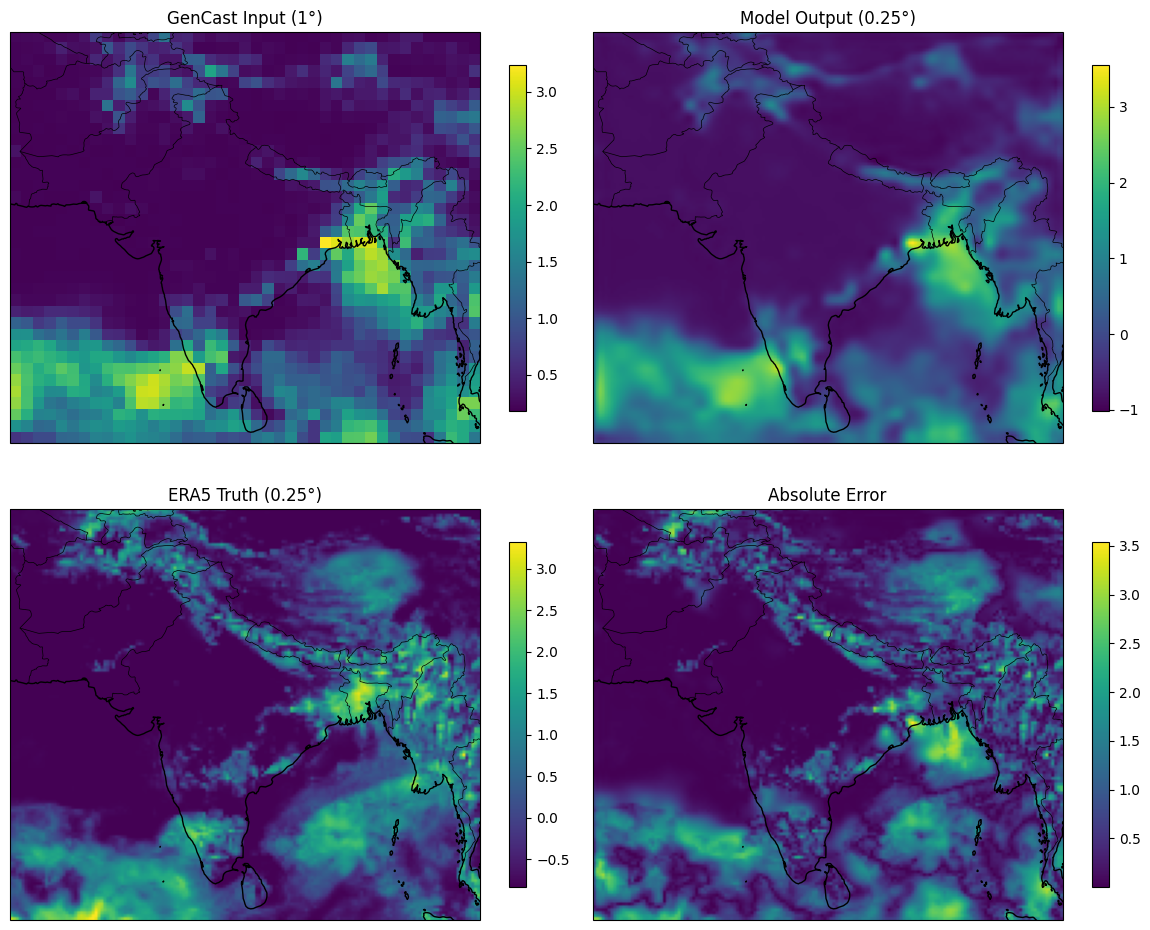

In [34]:
visualize_test_raw(model, test_ds, device, idx=10)

In [51]:
@torch.no_grad()
def evaluate_test(model, dataset, device):

    model.eval()

    preds, gts, base_preds = [], [], []

    for i in range(len(dataset)):

        s = dataset[i]

        # -------------------------
        # Input + condition
        # -------------------------
        x = s["inputs"].unsqueeze(0).to(device)
        y = s["targets"].unsqueeze(0)

        cond = torch.stack(
            (s["day_of_year"].unsqueeze(0),
             s["hour"].unsqueeze(0)), 1
        ).to(device)

        # -------------------------
        # Model prediction
        # -------------------------
        pred = model(x, cond).cpu()

        # -------------------------
        # Baseline (upsampled input)
        # -------------------------
        inp = s["inputs"][0].cpu().numpy()
        inp = inp * dataset.train_std.item() + dataset.train_mean.item()

        inp_tensor = torch.from_numpy(inp).unsqueeze(0).unsqueeze(0)

        base = torch.nn.functional.interpolate(
            inp_tensor,
            size=pred.shape[-2:],
            mode="bilinear"
        )

        # -------------------------
        # Store
        # -------------------------
        preds.append(pred)
        base_preds.append(base)
        gts.append(y)

    preds = torch.cat(preds)
    base_preds = torch.cat(base_preds)
    gts = torch.cat(gts)

    # -------------------------
    # Metrics
    # -------------------------
    mse_model, mae_model, r2_model = compute_metrics(preds, gts)
    mse_base,  mae_base,  r2_base  = compute_metrics(base_preds, gts)

    # print("\n===== TEST RESULTS =====")
    # print("Baseline (GenCast → interp):")
    # print(f"MSE: {mse_base:.4f} | MAE: {mae_base:.4f} | R2: {r2_base:.4f}")

    # print("\nModel:")
    # print(f"MSE: {mse_model:.4f} | MAE: {mae_model:.4f} | R2: {r2_model:.4f}")

    # -------------------------
    # Improvement
    # -------------------------
    print("\nImprovement:")
    print(f"MSE ↓ {(mse_base - mse_model)/mse_base * 100:.2f}%")
    print(f"MAE ↓ {(mae_base - mae_model)/mae_base * 100:.2f}%")
    print(f"R2  ↑ {(r2_model - r2_base):.4f}")

In [52]:
evaluate_test(model, test_ds, device)


Improvement:
MSE ↓ 34.91%
MAE ↓ 33.06%
R2  ↑ 0.6375


In [36]:
# @torch.no_grad()
# def evaluate_test_monthwise(model, dataset, device):

#     model.eval()

#     # store results per month
#     results = {
#         6: {"preds": [], "gts": []},
#         7: {"preds": [], "gts": []},
#         8: {"preds": [], "gts": []},
#         9: {"preds": [], "gts": []},
#     }

#     for i in range(len(dataset)):

#         s = dataset[i]

#         # -------------------------
#         # Get month from day_of_year
#         # -------------------------
#         doy = s["day_of_year"].item() * 360
#         month = int(doy // 30) + 1   # inverse of your encoding

#         if month not in results:
#             continue

#         # -------------------------
#         # Input + condition
#         # -------------------------
#         x = s["inputs"].unsqueeze(0).to(device)
#         y = s["targets"].unsqueeze(0)

#         cond = torch.stack(
#             (s["day_of_year"].unsqueeze(0),
#              s["hour"].unsqueeze(0)), 1
#         ).to(device)

#         # -------------------------
#         # Prediction
#         # -------------------------
#         pred = model(x, cond).cpu()

#         # -------------------------
#         # Store
#         # -------------------------
#         results[month]["preds"].append(pred)
#         results[month]["gts"].append(y)

#     # -------------------------
#     # Compute metrics
#     # -------------------------
#     print("\n===== MONTH-WISE TEST RESULTS =====\n")

#     for m in [6,7,8,9]:

#         if len(results[m]["preds"]) == 0:
#             continue

#         preds = torch.cat(results[m]["preds"])
#         gts   = torch.cat(results[m]["gts"])

#         mse, mae, r2 = compute_metrics(preds, gts)

#         print(f"Month {m}:")
#         print(f"  MSE: {mse:.4f}")
#         print(f"  MAE: {mae:.4f}")
#         print(f"  R2 : {r2:.4f}\n")

In [37]:
# evaluate_test_monthwise(model, test_ds, device)

In [38]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F

# T = 1000  # diffusion steps

# def linear_beta_schedule(timesteps):
#     beta_start = 1e-4
#     beta_end   = 0.02
#     return torch.linspace(beta_start, beta_end, timesteps)

# betas = linear_beta_schedule(T)
# alphas = 1. - betas
# alphas_cumprod = torch.cumprod(alphas, dim=0)

In [39]:
# def q_sample(x0, t, noise):

#     sqrt_alpha_hat = torch.sqrt(alphas_cumprod[t])[:, None, None, None]
#     sqrt_one_minus = torch.sqrt(1 - alphas_cumprod[t])[:, None, None, None]

#     return sqrt_alpha_hat * x0 + sqrt_one_minus * noise

In [40]:
# class TimeEmbedding(nn.Module):
#     def __init__(self, dim):
#         super().__init__()
#         self.linear = nn.Sequential(
#             nn.Linear(1, dim),
#             nn.SiLU(),
#             nn.Linear(dim, dim)
#         )

#     def forward(self, t):
#         return self.linear(t.unsqueeze(-1))

In [41]:
# class DiffusionUNet(nn.Module):

#     def __init__(self, in_c=3, cond_dim=2):
#         super().__init__()

#         self.time_embed = TimeEmbedding(128)
#         self.cond_embed = nn.Linear(cond_dim, 128)

#         self.unet = UNet(in_c + 1, 1)  
#         # +1 because noisy target is concatenated

#     def forward(self, x_cond, x_noisy, t, cond):

#         t_emb = self.time_embed(t)
#         c_emb = self.cond_embed(cond)

#         emb = t_emb + c_emb

#         # concat noisy target + conditioning input
#         x = torch.cat([x_noisy, x_cond], dim=1)

#         return self.unet(x, emb)

In [42]:
# def diffusion_loss(model, batch, device):

#     x_cond = batch["inputs"].to(device)   # [B,3,36,41]
#     x0     = batch["targets"].to(device)  # [B,1,141,161]

#     # upscale conditioning to match resolution
#     x_cond = F.interpolate(x_cond, size=x0.shape[-2:])

#     cond = torch.stack(
#         (batch["day_of_year"], batch["hour"]), 1
#     ).to(device)

#     B = x0.shape[0]

#     t = torch.randint(0, T, (B,), device=device).long()

#     noise = torch.randn_like(x0)

#     x_noisy = q_sample(x0, t, noise)

#     pred_noise = model(x_cond, x_noisy, t.float()/T, cond)

#     return F.mse_loss(pred_noise, noise)

In [43]:
# def train_diffusion(model, loader, optimizer, device):

#     model.train()
#     total = 0

#     for batch in loader:

#         loss = diffusion_loss(model, batch, device)

#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()

#         total += loss.item()

#     return total / len(loader)

In [44]:
# @torch.no_grad()
# def sample(model, x_cond, cond, device):

#     model.eval()

#     x = torch.randn((1,1,141,161)).to(device)

#     x_cond = F.interpolate(x_cond, size=(141,161))

#     for t in reversed(range(T)):

#         t_tensor = torch.tensor([t], device=device).float()/T

#         pred_noise = model(x_cond, x, t_tensor, cond)

#         alpha = alphas[t]
#         alpha_hat = alphas_cumprod[t]

#         beta = betas[t]

#         if t > 0:
#             noise = torch.randn_like(x)
#         else:
#             noise = torch.zeros_like(x)

#         x = (1/torch.sqrt(alpha)) * (
#             x - ((1 - alpha) / torch.sqrt(1 - alpha_hat)) * pred_noise
#         ) + torch.sqrt(beta) * noise

#     return x

In [45]:
# device = "cuda"

# model = DiffusionUNet(in_c=3).to(device)

# optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

In [46]:
# for epoch in range(20):

#     loss = train_diffusion(model, train_loader, optimizer, device)

#     print(f"Epoch {epoch} | Loss: {loss:.4f}")